<a href="https://colab.research.google.com/github/mnskartik/CodEvo-Solutions-ML/blob/main/CAT_DOG2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator




In [19]:
from google.colab import files
uploaded = files.upload()  # Upload the ZIP file interactively

import zipfile
import os

# Unzip the file
zip_file_path = '/content/content/dogs_vs_cats.zip'
extracted_dir = '/content/extracted_images'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)

print(f"Extracted files are available at: {extracted_dir}")


Saving dogs_vs_cats.zip to dogs_vs_cats.zip
Extracted files are available at: /content/extracted_images


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [39]:
# Set paths
data_dir =  '/content/content/extracted_images/dogs_vs_cats/test' # Update to the extracted directory
categories = ['cats', 'dogs']

# Prepare data
data = []
img_size = 128

print(f"Checking for images in: {data_dir}")  # Debug: Print the data directory
for category in categories:
    path = os.path.join(data_dir, category)
    class_num = categories.index(category)
    print(f"Checking for images in: {path}")  # Debug: Print the category path
    for img in os.listdir(path):
        print(f"Processing image: {img}")   # Debug: Print the image filename
        img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
        if img_array is None:
            print(f"Warning: Could not load image: {os.path.join(path, img)}")
            continue
        img_resized = cv2.resize(img_array, (img_size, img_size))
        data.append([img_resized, class_num])

print(f"Number of images loaded: {len(data)}") # Debug: Print the number of images loaded

np.random.shuffle(data)


Streaming output truncated to the last 5000 lines.
Processing image: cat.5280.jpg
Processing image: cat.1913.jpg
Processing image: cat.7609.jpg
Processing image: cat.9509.jpg
Processing image: cat.6858.jpg
Processing image: cat.5837.jpg
Processing image: cat.5499.jpg
Processing image: cat.7507.jpg
Processing image: cat.3557.jpg
Processing image: cat.7134.jpg
Processing image: cat.9387.jpg
Processing image: cat.7359.jpg
Processing image: cat.5728.jpg
Processing image: cat.933.jpg
Processing image: cat.11224.jpg
Processing image: cat.2777.jpg
Processing image: cat.1371.jpg
Processing image: cat.8735.jpg
Processing image: cat.5058.jpg
Processing image: cat.11632.jpg
Processing image: cat.2345.jpg
Processing image: cat.11660.jpg
Processing image: cat.7929.jpg
Processing image: cat.5183.jpg
Processing image: cat.236.jpg
Processing image: cat.11616.jpg
Processing image: cat.3278.jpg
Processing image: cat.6541.jpg
Processing image: cat.10597.jpg
Processing image: cat.6595.jpg
Processing image

In [40]:
np.random.shuffle(data)
X = []
y = []

for features, label in data:
    X.append(features)
    y.append(label)

X = np.array(X).reshape(-1, img_size, img_size, 3)
y = np.array(y)

X = X / 255.0  # Normalize the data

Applying Transformations

In [41]:
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

datagen.fit(X)

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_size, img_size, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])



In [44]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Assuming X and y are your image data and labels
# Split your data into training and validation sets *before* using ImageDataGenerator
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize ImageDataGenerator with any desired preprocessing or augmentation
datagen = ImageDataGenerator(rescale=1./255)  # Rescale pixel values to [0, 1]

# Create data generators for training and validation sets separately
train_generator = datagen.flow(X_train, y_train, batch_size=32)
val_generator = datagen.flow(X_val, y_val, batch_size=32)

# Fit the model using the generators
history = model.fit(train_generator,
                    epochs=20,
                    validation_data=val_generator)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


125/125 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.5108 - loss: 0.6936 - val_accuracy: 0.4790 - val_loss: 0.6933
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.4985 - loss: 0.6932 - val_accuracy: 0.4790 - val_loss: 0.6933
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.5058 - loss: 0.6931 - val_accuracy: 0.4790 - val_loss: 0.6934
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.5036 - loss: 0.6933 - val_accuracy: 0.4790 - val_loss: 0.6935
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.5127 - loss: 0.6930 - val_accuracy: 0.4790 - val_loss: 0.6935
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 195s 2s/step - accuracy: 0.5048 - loss: 0.6931 - val_accuracy: 0.4790 - val_loss: 0.6936
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.5136 - loss: 0.6930 - val_accuracy: 0.4790 - val_loss: 0.6934
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.5034 - loss: 0.6931 - val_accuracy: 0.479

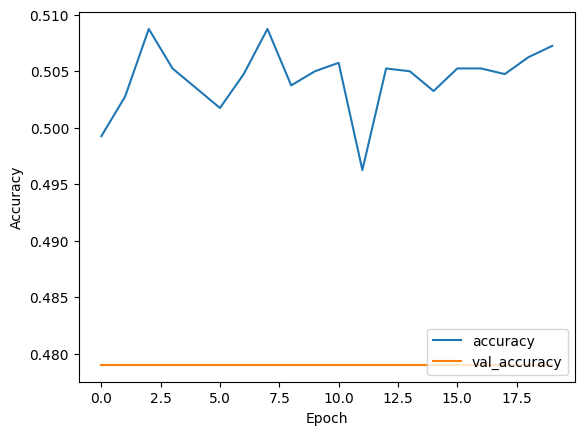

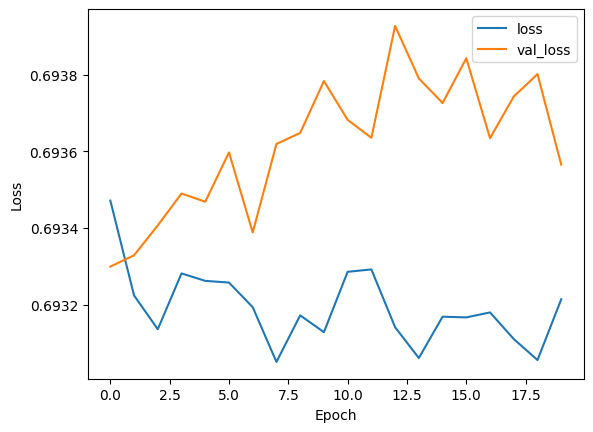

In [45]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()


In [46]:
predictions = model.predict(X)


157/157 ━━━━━━━━━━━━━━━━━━━━ 65s 413ms/step


In [53]:
!pip install streamlit
import streamlit as st
# Make prediction
prediction = model.predict(X)

if prediction.shape[-1] == 1:  # Binary classification
    label = "Dog" if prediction[0][0] > 0.5 else "Cat"
    confidence = prediction[0][0] if prediction[0][0] > 0.5 else 1 - prediction[0][0]
else:  # For multi-class classification, adjust accordingly
    label = "Dog" if np.argmax(prediction) == 1 else "Cat"
    confidence = np.max(prediction)

# Display the result
st.write(f"The image is classified as: **{label}**")
st.write(f"Confidence: **{confidence:.2f}**")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.4/23.4 MB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.7 MB/s eta 0:00:00
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 381ms/step


2024-12-11 15:00:35.940 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-11 15:00:36.103 
  command:

    streamlit run /usr/local/lib/python3.10/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2024-12-11 15:00:36.105 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-11 15:00:36.110 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-11 15:00:36.113 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-11 15:00:36.118 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-11 15:00:36.120 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2024-12-11 15:00:36.122 Thread 'MainThread': mi

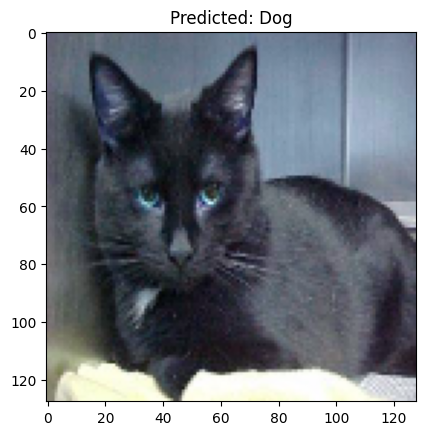

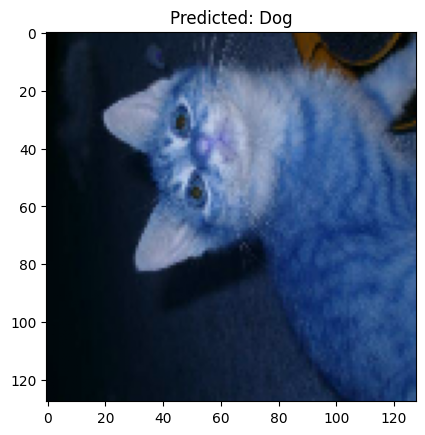

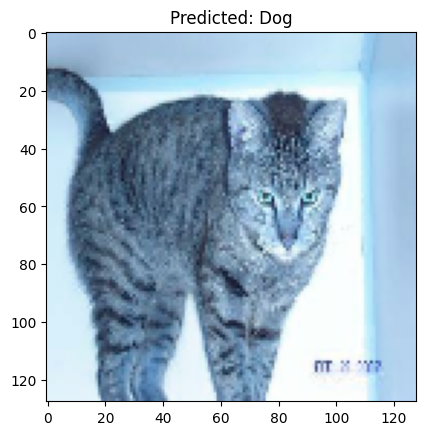

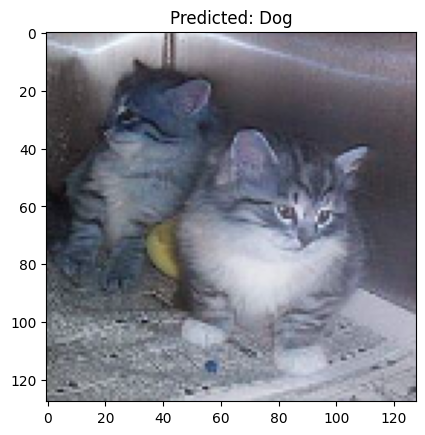

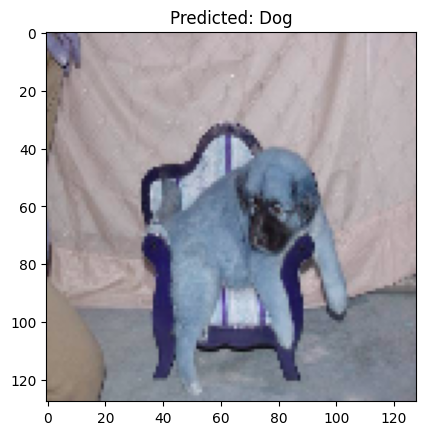

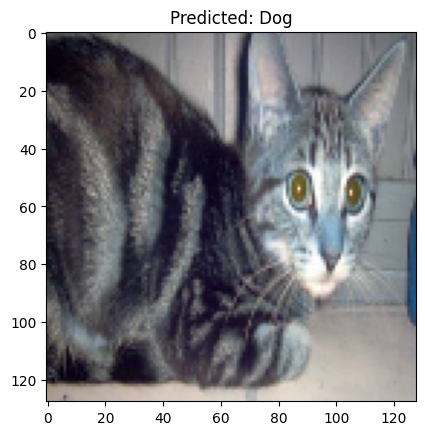

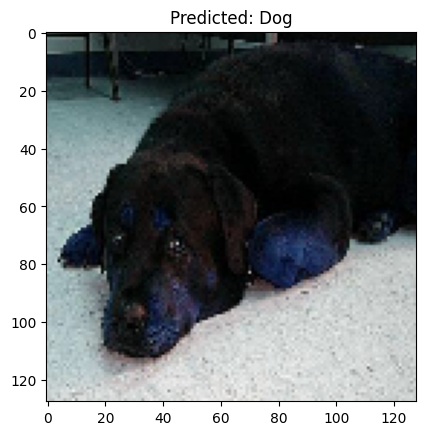

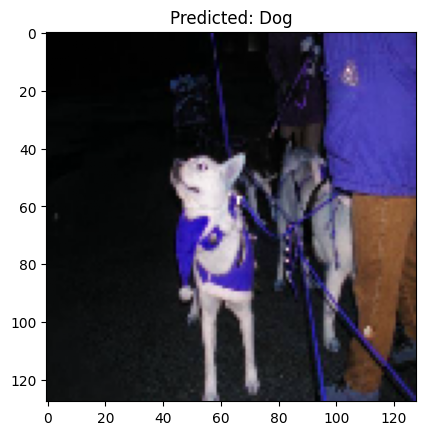

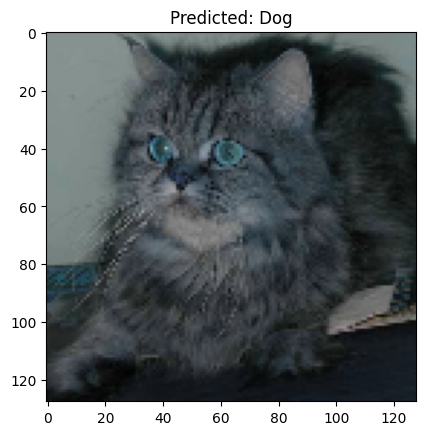

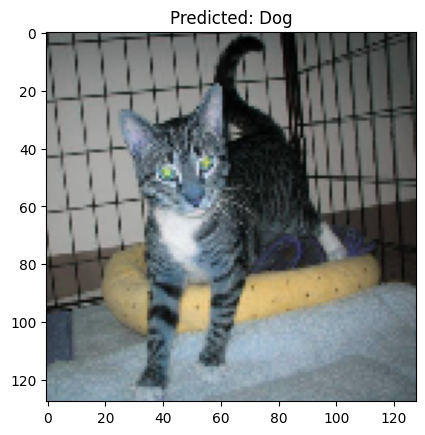

In [54]:
for i in range(10):
    plt.imshow(X[i])
    plt.title(f"Predicted: {'Dog' if predictions[i] > 0.5 else 'Cat'}")
    plt.show()


In [48]:
model.save("model.h5")
